# Mobile-First Semantic-Guided Aerial Classification CNN with Activation-Aware Weight Quantisation

This notebook covers the Lucas semantic segmentation and quantisation workflow for the CSC3109 Group 12 aerial-image classification project.

The focus is not only classification accuracy. The priority is an edge-oriented model that keeps useful spatial semantics, remains compact enough for constrained deployment targets, and stays stable after INT8-style quantisation.

## Notebook provenance and training disclaimer

This is a **results reproduction and presentation notebook**. The expensive stages were run through project scripts and saved as reproducible artifacts under `reports/tables/` and `reports/figures/`.

Heavy jobs were run on a RTX 3090 server. With research evals on a RTX Quadro 6000. This notebook loads the saved outputs, checks that required artifacts exist, and renders report-ready tables and figures.

The Training process required complex orchestration that is difficult to perform from jupyter, hence it was performed outside this notebook using the repository scripts below:

Where to find the source scripts/configs:

- SAM3 mask config: `configs/semantic_sam3_class_aware.yaml`
- SAM3 pseudo-mask generation: `tools/generate_sam3_class_aware_masks.py`
- Semantic-Guided CG-AF CNN LoveDA training: `src/training/train_loveda_semantic_guided.py`
- Semantic-Guided CG-AF CNN full-size LoveDA evaluation: `tools/evaluate_loveda_fullsize.py`
- Semantic-Guided CG-AF CNN semantic transfer/classification training: `src/training/train_semantic_guided_transfer.py`
- QAT utilities: `src/training/qat.py`
- PTQ/AWQ quantisation evaluation: `tools/evaluate_semantic_guided_quant.py`
- Native ONNX FP32 export: `tools/export_semantic_guided_onnx.py`
- Native ONNX INT8 QDQ evaluation: `tools/evaluate_semantic_guided_onnx.py`
- Unseen ImageFolder ONNX/Torch comparison: `tools/evaluate_semantic_guided_unseen_imagefolder.py`
- Unseen review artifact generation: `tools/create_semantic_guided_unseen_review_artifacts.py`
- Semantic-Guided CG-AF CNN model API: `src/models/semantic_guided_cgaf.py`

Without further ado, let's get into it.

## 1. Question

> Can we build an edge-optimised aerial scene model that uses spatially aware semantic segmentation to achieve strong classification accuracy while remaining stable after INT8 quantisation?

Target scene classes:

- `bridge`
- `freeway`
- `overpass`
- `railway`

## 2. Motivation: edge deployment first

Deployment target matters here. Drones and satellite/onboard remote-sensing platforms are constrained by compute, memory, power, thermal budget, and connectivity. For these systems, compact quantised models are not just an implementation detail; they are part of the research objective.

Mobile and embedded NPUs commonly prioritise INT8-style inference paths, so a useful aerial scene model should not only be accurate in FP32 but also remain stable after quantisation. Exploring parameter-efficient, INT8-ready models sits on the practical Pareto frontier between accuracy, latency, memory, and energy cost.

This notebook tackles that problem directly.

## 3. Why semantic-guided classification?

Standard image-level classifiers compress spatial evidence into a single scene prediction. For aerial infrastructure classes, this can hide the geometric and topological cues that distinguish bridges, freeways, overpasses, and railways.

A bridge, freeway, overpass, or railway is often defined by shape, continuity, crossings, and surrounding context. A segmentation-guided classifier gives the model an intermediate dense semantic representation before making the final image-level decision.

The goal is therefore twofold:

1. predict useful semantic regions;
2. use those predicted regions to guide final scene classification.

## 4. Semantic mask generation and data distillation

The project dataset provides image-level labels, but it does not provide pixel-level semantic masks. This means there is no semantic equivalent of the dataset available for supervised segmentation training.

To create dense semantic supervision without manual annotation, Meta/Facebook SAM3 via Hugging Face was used for open-vocabulary segmentation mask generation. The generated masks are treated as pseudo-labels for semantic distillation, not as ground truth.

Important deployment point:

- SAM3 is used offline during data preparation.
- SAM3 is not deployed at inference time.
- The deployed model is the compact CNN model only.

## 5. Model overview

The final model is a CNN-based semantic-guided classifier. It uses:

- a ConvNeXt-Tiny encoder;
- a custom context-gated asymmetric fusion decoder;
- a segmentation head producing dense semantic logits;
- a scene classification head guided by predicted semantic regions.

Model outputs:

```text
1. segmentation_logits
2. scene_logits
```

## 6. Full pipeline

The full pipeline is:

```text
1. ImageNet/timm ConvNeXt prior
2. Semantic-Guided CG-AF CNN LoveDA semantic segmentation pretraining
3. SAM3 class-aware pseudo-mask generation
4. Semantic distillation on the project dataset
5. Segmentation-guided scene classification
6. W8A8 quantisation-aware training
7. AWQ-style activation-aware robustness proxy evaluation
8. Native ONNX INT8 QDQ export/evaluation for deployment
```

The notebook reproduces the pipeline from saved experiment artifacts rather than retraining all models inside the notebook.

## 7. Run protocol

This notebook is intended to be run top-to-bottom for report-ready tables and figures. It reads saved metrics, figures, and checkpoints generated by the training/evaluation scripts.

Protocol:

- Do not regenerate SAM3 masks inside this notebook.
- Do not retrain LoveDA or SAM3-transfer models inside this notebook.
- Load existing CSV/JSON metrics from `reports/tables/`.
- Link existing qualitative figures from `reports/figures/`.
- Use the notebook to make the final results reproducible, readable, and presentation-ready.

## 8. Setup

In [1]:
from pathlib import Path
from io import BytesIO
import ast
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, Markdown, display

try:
    from PIL import Image as PILImage
except ImportError:  # pragma: no cover - fallback for minimal notebook environments
    PILImage = None

pd.set_option('display.max_columns', 80)
pd.set_option('display.width', 180)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.grid'] = True

CLASS_NAMES = ['bridge', 'freeway', 'overpass', 'railway']
DISPLAY_EXTENDED_QUALITATIVE_FIGURES = False

def find_project_root() -> Path:
    cwd = Path.cwd().resolve()
    candidates = [cwd, cwd.parent, cwd.parent.parent]
    for candidate in candidates:
        if (candidate / 'reports').exists() and (candidate / 'notebooks').exists():
            return candidate
    raise FileNotFoundError('Could not locate project root containing reports/ and notebooks/.')

PROJECT_ROOT = find_project_root()
TABLES_DIR = PROJECT_ROOT / 'reports' / 'tables'
FIGURES_DIR = PROJECT_ROOT / 'reports' / 'figures'

def load_csv(path: Path) -> pd.DataFrame:
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(path)
    return pd.read_csv(path)

def load_json(path: Path) -> dict:
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(path)
    return json.loads(path.read_text())

def one_artifact(root: Path, pattern: str) -> Path:
    matches = sorted(root.glob(pattern))
    if len(matches) != 1:
        raise FileNotFoundError(f'Expected exactly one artifact for {root / pattern}, found {len(matches)}')
    return matches[0]

def first_artifact(root: Path, patterns: list[str]) -> Path:
    for pattern in patterns:
        matches = sorted(root.glob(pattern))
        if matches:
            return matches[0]
    raise FileNotFoundError(f'No artifact matched patterns {patterns!r} under {root}')

def rounded(df: pd.DataFrame, digits: int = 4) -> pd.DataFrame:
    out = df.copy()
    for column in out.select_dtypes(include='number').columns:
        out[column] = out[column].round(digits)
    return out

def display_table(df: pd.DataFrame, title: str | None = None, digits: int = 4) -> None:
    if title:
        display(Markdown(f'**{title}**'))
    display(rounded(df, digits=digits))

def display_image_artifact(
    path: Path,
    title: str | None = None,
    width: int = 1100,
    max_embed_width: int = 1600,
) -> None:
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(path)
    if title:
        display(Markdown(f'**{title}**'))
    if PILImage is None:
        display(Image(filename=str(path), width=width))
        return
    with PILImage.open(path) as image:
        image = image.convert('RGB')
        if image.width > max_embed_width:
            scale = max_embed_width / image.width
            image = image.resize((max_embed_width, int(image.height * scale)))
        buffer = BytesIO()
        image.save(buffer, format='JPEG', quality=88, optimize=True)
    display(Image(data=buffer.getvalue(), format='jpeg', width=width))

print(f'Project root: {PROJECT_ROOT}')

Project root: /home/lucas/Projects/machinelearning/CSC3109_Project


## 9. Required artifacts

The notebook is artifact-first. It expects the saved experiment results to already exist locally.

In [2]:
loveda_eval_dir = TABLES_DIR / 'loveda_fullsize_eval'
latest_pipeline_manifests = sorted(TABLES_DIR.glob('semantic_guided_cgaf_pipeline_*/semantic_guided_cgaf_pipeline_manifest.json'))
def valid_pipeline_manifest(path: Path) -> dict | None:
    payload = load_json(path)
    required_stages = {'quant', 'mask-export', 'jupyter-artifacts'}
    stages = set(payload.get('stages', []))
    expected_artifacts = {
        'quant_summary', 'model_size_summary', 'checkpoint_export_manifest',
        'fft_raw_checkpoint_export', 'peft_raw_checkpoint_export',
        'fft_awq_checkpoint', 'peft_awq_checkpoint',
        'mask_export_manifest', 'mask_export_summary', 'mask_export_summary_csv', 'mask_figure_dir',
    }
    status = payload.get('artifact_status')
    if not isinstance(status, list) or not status:
        return None
    status_by_artifact = {row.get('artifact'): row for row in status}
    if not expected_artifacts.issubset(status_by_artifact):
        return None
    def status_path_exists(row: dict) -> bool:
        raw_path = Path(str(row.get('path', '')))
        path = raw_path if raw_path.is_absolute() else PROJECT_ROOT / raw_path
        return path.exists()
    missing_required = [row for row in status if row.get('required') and not status_path_exists(row)]
    return payload if required_stages.issubset(stages) and not missing_required else None

PIPELINE_MANIFEST_PATH = None
PIPELINE_MANIFEST = None
for candidate in reversed(latest_pipeline_manifests):
    PIPELINE_MANIFEST = valid_pipeline_manifest(candidate)
    if PIPELINE_MANIFEST is not None:
        PIPELINE_MANIFEST_PATH = candidate
        break
if PIPELINE_MANIFEST_PATH is None:
    raise FileNotFoundError('Run tools/run_semantic_guided_pipeline.py with quant, mask-export, and jupyter-artifacts stages first.')

def pipeline_output_path(key: str) -> Path:
    value = PIPELINE_MANIFEST['outputs'][key]
    path = Path(value)
    return path if path.is_absolute() else PROJECT_ROOT / path

actual_quant_dir = pipeline_output_path('quant_summary').parent
mask_export_manifest_path = pipeline_output_path('mask_export_manifest')
mask_export_summary_path = pipeline_output_path('mask_export_summary')
mask_export_summary_csv_path = pipeline_output_path('mask_export_summary_csv')
mask_figure_dir = pipeline_output_path('mask_figure_dir')
loveda_figures_dir = one_artifact(FIGURES_DIR / 'loveda_predictions', '*cgaf128')
sam3_transfer_figures_dir = one_artifact(FIGURES_DIR, '*semantic_sam3_20260614_164100')
compute_source_path = next(
    path
    for path in sorted(TABLES_DIR.glob('*compute_comparison_512_estimated.csv'))
    if load_csv(path)['run_id'].str.contains('cgaf128', regex=False).any()
)

TABLE_ARTIFACTS = {
    'Semantic-Guided CG-AF CNN LoveDA summary': one_artifact(loveda_eval_dir, '*cgaf128*recipe*fullsize_summary.csv'),
    'Semantic-Guided CG-AF CNN LoveDA per-class': one_artifact(loveda_eval_dir, '*cgaf128*recipe*fullsize_per_class.csv'),
    'Semantic-Guided CG-AF CNN compute source row': compute_source_path,
    'SAM3 mask stats': TABLES_DIR / 'semantic_sam3_class_aware_mask_stats.json',
    'SAM3 transfer history': one_artifact(TABLES_DIR, '*semantic_sam3_20260614_164100/epoch_metrics_summary.csv'),
    'Pipeline manifest': PIPELINE_MANIFEST_PATH,
    'Actual quant summary': pipeline_output_path('quant_summary'),
    'Model size summary': pipeline_output_path('model_size_summary'),
    'Checkpoint export manifest': pipeline_output_path('checkpoint_export_manifest'),
    'AWQ W8A8 summary': mask_export_summary_csv_path,
    'AWQ example metadata': mask_export_manifest_path,
}
FIGURE_ARTIFACTS = {
    'Semantic-Guided CG-AF CNN LoveDA first examples': one_artifact(loveda_figures_dir, '*first_examples.png'),
    'Semantic-Guided CG-AF CNN LoveDA worst examples': one_artifact(loveda_figures_dir, '*worst_examples.png'),
    'Semantic-Guided CG-AF CNN SAM3 example grid': sam3_transfer_figures_dir / 'mask_prediction_examples_best_grid.png',
    'AWQ mask review figure dir': mask_figure_dir,
}
ARTIFACTS = {**TABLE_ARTIFACTS, **FIGURE_ARTIFACTS}

artifact_status = pd.DataFrame(
    [
        {
            'kind': 'table/json' if name in TABLE_ARTIFACTS else 'figure',
            'artifact': name,
            'exists': path.exists(),
            'path': str(path.relative_to(PROJECT_ROOT)),
        }
        for name, path in ARTIFACTS.items()
    ]
)
display_table(artifact_status[['kind', 'artifact', 'exists']], 'Artifact availability', digits=4)
missing = artifact_status.loc[~artifact_status['exists'], 'path'].tolist()
assert not missing, 'Missing required artifacts: ' + ', '.join(missing)

**Artifact availability**

,kind,artifact,exists
0,table/json,Semantic-Guided CG-AF CNN LoveDA summary,True
1,table/json,Semantic-Guided CG-AF CNN LoveDA per-class,True
2,table/json,Semantic-Guided CG-AF CNN compute source row,True
3,table/json,SAM3 mask stats,True
4,table/json,SAM3 transfer history,True
5,table/json,Actual quant summary,True
6,table/json,Model size summary,True
7,table/json,AWQ W8A8 summary,True
8,table/json,AWQ W8A8 per-scene,True
9,table/json,AWQ example metadata,True


## 10. Semantic-Guided CG-AF CNN LoveDA pretraining result

The Semantic-Guided CG-AF CNN is the selected segmentation architecture for this workflow. LoveDA pretraining gives the model a dense aerial segmentation prior before semantic distillation on the project dataset.

In [3]:
loveda_summary = load_csv(ARTIFACTS['Semantic-Guided CG-AF CNN LoveDA summary'])
loveda_per_class = load_csv(ARTIFACTS['Semantic-Guided CG-AF CNN LoveDA per-class'])
compute_all = load_csv(ARTIFACTS['Semantic-Guided CG-AF CNN compute source row'])
semantic_guided_compute = compute_all.loc[compute_all['run_id'].str.contains('cgaf128', regex=False)].copy()
assert not semantic_guided_compute.empty, 'Expected Semantic-Guided CG-AF CNN compute row was not found.'
assert {'mean_iou', 'mean_dice', 'pixel_accuracy'}.issubset(loveda_summary.columns), 'LoveDA summary schema changed.'

loveda_view = loveda_summary[[
    'backbone', 'fpn_channels', 'checkpoint_epoch', 'image_size',
    'mean_iou', 'mean_dice', 'pixel_accuracy'
]].copy()
loveda_view.insert(0, 'model', 'Semantic-Guided CG-AF CNN')
compute_view = semantic_guided_compute[[
    'device', 'batch_size', 'total_params', 'trainable_params',
    'gmacs_512_estimated_from_256', 'latency_ms_per_batch', 'images_per_second'
]].rename(columns={
    'gmacs_512_estimated_from_256': 'estimated_gmacs_at_512',
    'latency_ms_per_batch': 'cpu_proxy_latency_ms_per_batch',
    'images_per_second': 'cpu_proxy_images_per_second',
})
compute_view.insert(0, 'model', 'Semantic-Guided CG-AF CNN')

display_table(loveda_view, 'Semantic-Guided CG-AF CNN full-size LoveDA validation metrics')
display_table(compute_view, 'Semantic-Guided CG-AF CNN compute summary, CPU proxy only')
display_table(loveda_per_class[['class_name', 'iou', 'dice']], 'Semantic-Guided CG-AF CNN LoveDA per-class segmentation metrics')

**Semantic-Guided CG-AF CNN full-size LoveDA validation metrics**

,model,backbone,fpn_channels,checkpoint_epoch,image_size,mean_iou,mean_dice,pixel_accuracy
0,Semantic-Guided CG-AF CNN,convnext_tiny.in12k_ft_in1k,128,8,1024,0.5581,0.7115,0.7222


**Semantic-Guided CG-AF CNN compute summary, CPU proxy only**

,model,device,batch_size,total_params,trainable_params,estimated_gmacs_at_512,cpu_proxy_latency_ms_per_batch,cpu_proxy_images_per_second
3,Semantic-Guided CG-AF CNN,cpu,1,28100457,28100457,24.588,34.6673,28.8456


**Semantic-Guided CG-AF CNN LoveDA per-class segmentation metrics**

,class_name,iou,dice
0,background,0.5432,0.7040
1,building,0.6369,0.7782
2,road,0.5784,0.7329
3,water,0.6922,0.8181
4,barren,0.3918,0.5630
5,forest,0.4667,0.6364
6,agriculture,0.5977,0.7482


### Semantic-Guided CG-AF CNN qualitative LoveDA examples

These saved figures show full-size LoveDA predictions for the selected Semantic-Guided CG-AF CNN architecture. They are displayed from resolved artifact paths instead of Markdown-relative image links so they render reliably regardless of where Jupyter is launched.

**Semantic-Guided CG-AF CNN LoveDA first examples**

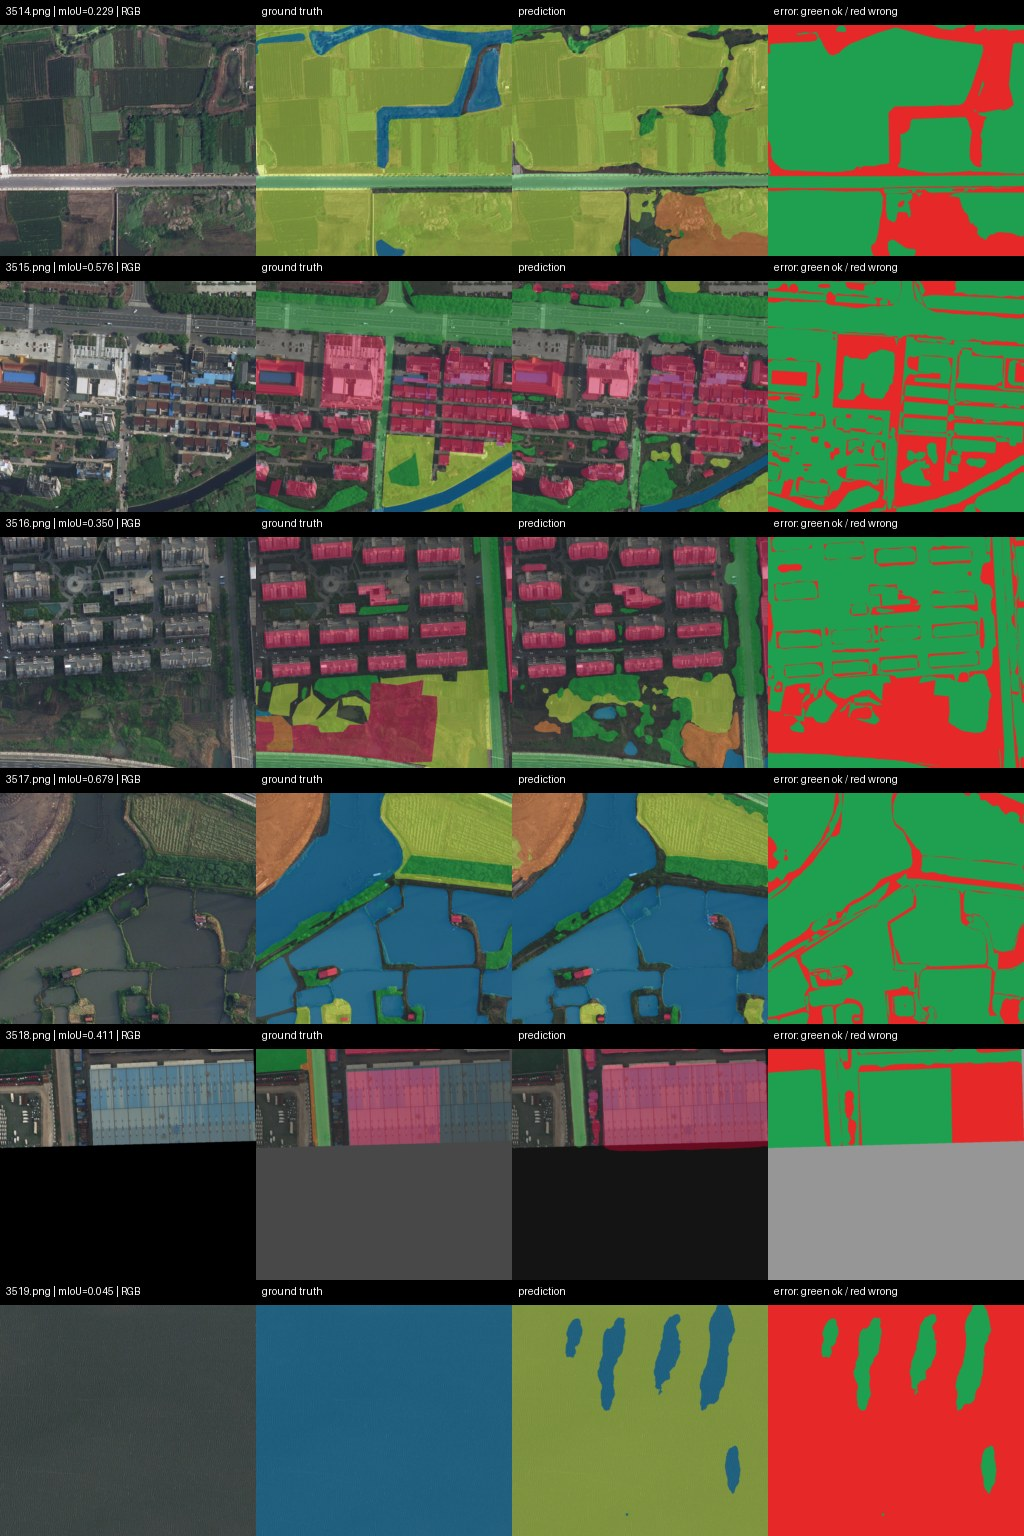

Extended LoveDA sheet omitted by default. Set `DISPLAY_EXTENDED_QUALITATIVE_FIGURES = True` to render it inline.

In [4]:
display_image_artifact(FIGURE_ARTIFACTS['Semantic-Guided CG-AF CNN LoveDA first examples'], 'Semantic-Guided CG-AF CNN LoveDA first examples')
if DISPLAY_EXTENDED_QUALITATIVE_FIGURES:
    display_image_artifact(FIGURE_ARTIFACTS['Semantic-Guided CG-AF CNN LoveDA worst examples'], 'Semantic-Guided CG-AF CNN LoveDA worst examples')
else:
    display(Markdown("Extended LoveDA sheet omitted by default. Set `DISPLAY_EXTENDED_QUALITATIVE_FIGURES = True` to render it inline."))

## 11. SAM3 class-aware pseudo-mask dataset

The original project dataset has image-level labels only. SAM3 was used offline to generate class-aware pseudo-masks, creating dense supervision for semantic distillation.

**SAM3 pseudo-mask manifest summary**

,metric,value
0,manifest_rows,2800
1,mask_schema,scene_v1
2,train_masks,2240
3,internal_tune_masks,560
4,usable_for_training,2800
5,successful_masks,2800


**SAM3 pseudo-mask class summary**

,scene_class,rows,success,foreground_coverage_mean,foreground_coverage_min,foreground_coverage_max,mask_area_px_mean
0,bridge,700,700,0.2382,0.0382,0.9991,15611.7014
1,freeway,700,700,0.5052,0.2074,0.9960,33110.5571
2,overpass,700,700,0.2299,0.0150,0.8876,15066.7143
3,railway,700,700,0.2474,0.0265,0.9972,16210.7843


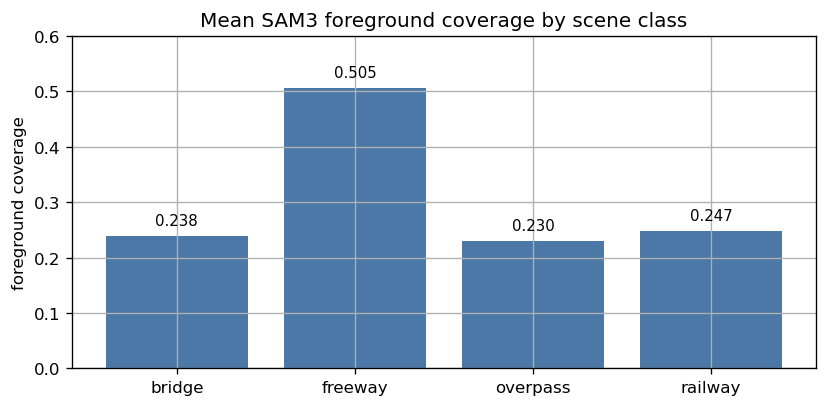

In [5]:
mask_stats = load_json(ARTIFACTS['SAM3 mask stats'])
mask_summary = pd.DataFrame([
    {'metric': 'manifest_rows', 'value': mask_stats['manifest_rows']},
    {'metric': 'mask_schema', 'value': mask_stats['mask_schema']},
    {'metric': 'train_masks', 'value': mask_stats['split_counts']['train']},
    {'metric': 'internal_tune_masks', 'value': mask_stats['split_counts']['internal_tune']},
    {'metric': 'usable_for_training', 'value': mask_stats['usable_for_training_counts']['true']},
    {'metric': 'successful_masks', 'value': mask_stats['status_counts']['success']},
])
class_stats = (
    pd.DataFrame.from_dict(mask_stats['class_stats'], orient='index')
    .reset_index()
    .rename(columns={'index': 'scene_class'})
)
class_stats_view = class_stats[[
    'scene_class', 'rows', 'success', 'foreground_coverage_mean', 'foreground_coverage_min', 'foreground_coverage_max', 'mask_area_px_mean'
]]

display_table(mask_summary, 'SAM3 pseudo-mask manifest summary')
display_table(class_stats_view, 'SAM3 pseudo-mask class summary')

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.bar(class_stats_view['scene_class'], class_stats_view['foreground_coverage_mean'], color='#4C78A8')
ax.set_title('Mean SAM3 foreground coverage by scene class')
ax.set_ylabel('foreground coverage')
ax.set_ylim(0, 0.6)
for index, value in enumerate(class_stats_view['foreground_coverage_mean']):
    ax.text(index, value + 0.015, f'{value:.3f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

## 12. Semantic distillation and segmentation-guided classification

The Semantic-Guided CG-AF CNN model is transferred from LoveDA segmentation to the project dataset using SAM3 pseudo-masks. The scene classifier is guided by the model's predicted semantic regions.

**Non-QAT Semantic-Guided CG-AF CNN SAM3 semantic transfer checkpoints**

,selection,epoch,train_accuracy,tune_accuracy,tune_macro_f1,tune_seg_pixel_accuracy,tune_seg_mean_iou,tune_seg_mean_dice,tune_loss,train_loss
0,best_segmentation_mIoU,10.0,1.0000,1.0,1.0,0.9317,0.8017,0.8861,0.6068,0.3537
1,first_best_macro_F1,3.0,0.9951,1.0,1.0,0.8948,0.7116,0.8226,0.6938,0.5440


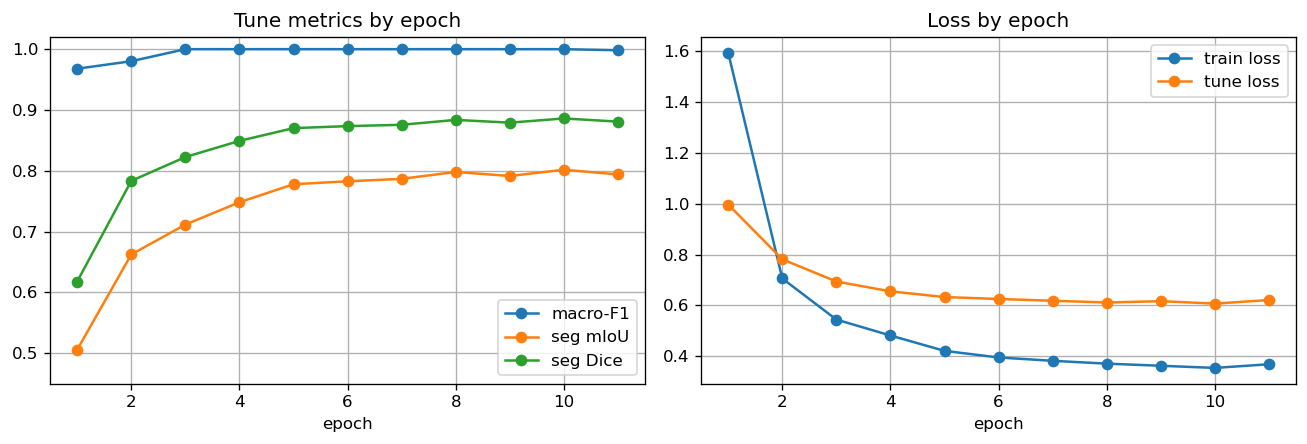

In [6]:
transfer_history = load_csv(ARTIFACTS['SAM3 transfer history'])
best_miou_row = transfer_history.loc[transfer_history['tune_seg_mean_iou'].idxmax()].copy()
best_f1_row = transfer_history.loc[transfer_history['tune_macro_f1'].idxmax()].copy()

best_transfer = pd.DataFrame([
    {'selection': 'best_segmentation_mIoU', **best_miou_row.to_dict()},
    {'selection': 'first_best_macro_F1', **best_f1_row.to_dict()},
])
display_table(best_transfer[[
    'selection', 'epoch', 'train_accuracy', 'tune_accuracy', 'tune_macro_f1',
    'tune_seg_pixel_accuracy', 'tune_seg_mean_iou', 'tune_seg_mean_dice', 'tune_loss', 'train_loss'
]], 'Non-QAT Semantic-Guided CG-AF CNN SAM3 semantic transfer checkpoints')

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
axes[0].plot(transfer_history['epoch'], transfer_history['tune_macro_f1'], marker='o', label='macro-F1')
axes[0].plot(transfer_history['epoch'], transfer_history['tune_seg_mean_iou'], marker='o', label='seg mIoU')
axes[0].plot(transfer_history['epoch'], transfer_history['tune_seg_mean_dice'], marker='o', label='seg Dice')
axes[0].set_title('Tune metrics by epoch')
axes[0].set_xlabel('epoch')
axes[0].set_ylim(0.45, 1.02)
axes[0].legend()

axes[1].plot(transfer_history['epoch'], transfer_history['train_loss'], marker='o', label='train loss')
axes[1].plot(transfer_history['epoch'], transfer_history['tune_loss'], marker='o', label='tune loss')
axes[1].set_title('Loss by epoch')
axes[1].set_xlabel('epoch')
axes[1].legend()
plt.tight_layout()
plt.show()

### SAM3 pseudo-mask transfer examples

The grid below compares the source image, SAM3 pseudo-mask, Semantic-Guided CG-AF CNN predicted mask, and overlay examples from the semantic transfer run.

**Semantic-Guided CG-AF CNN SAM3 semantic transfer examples**

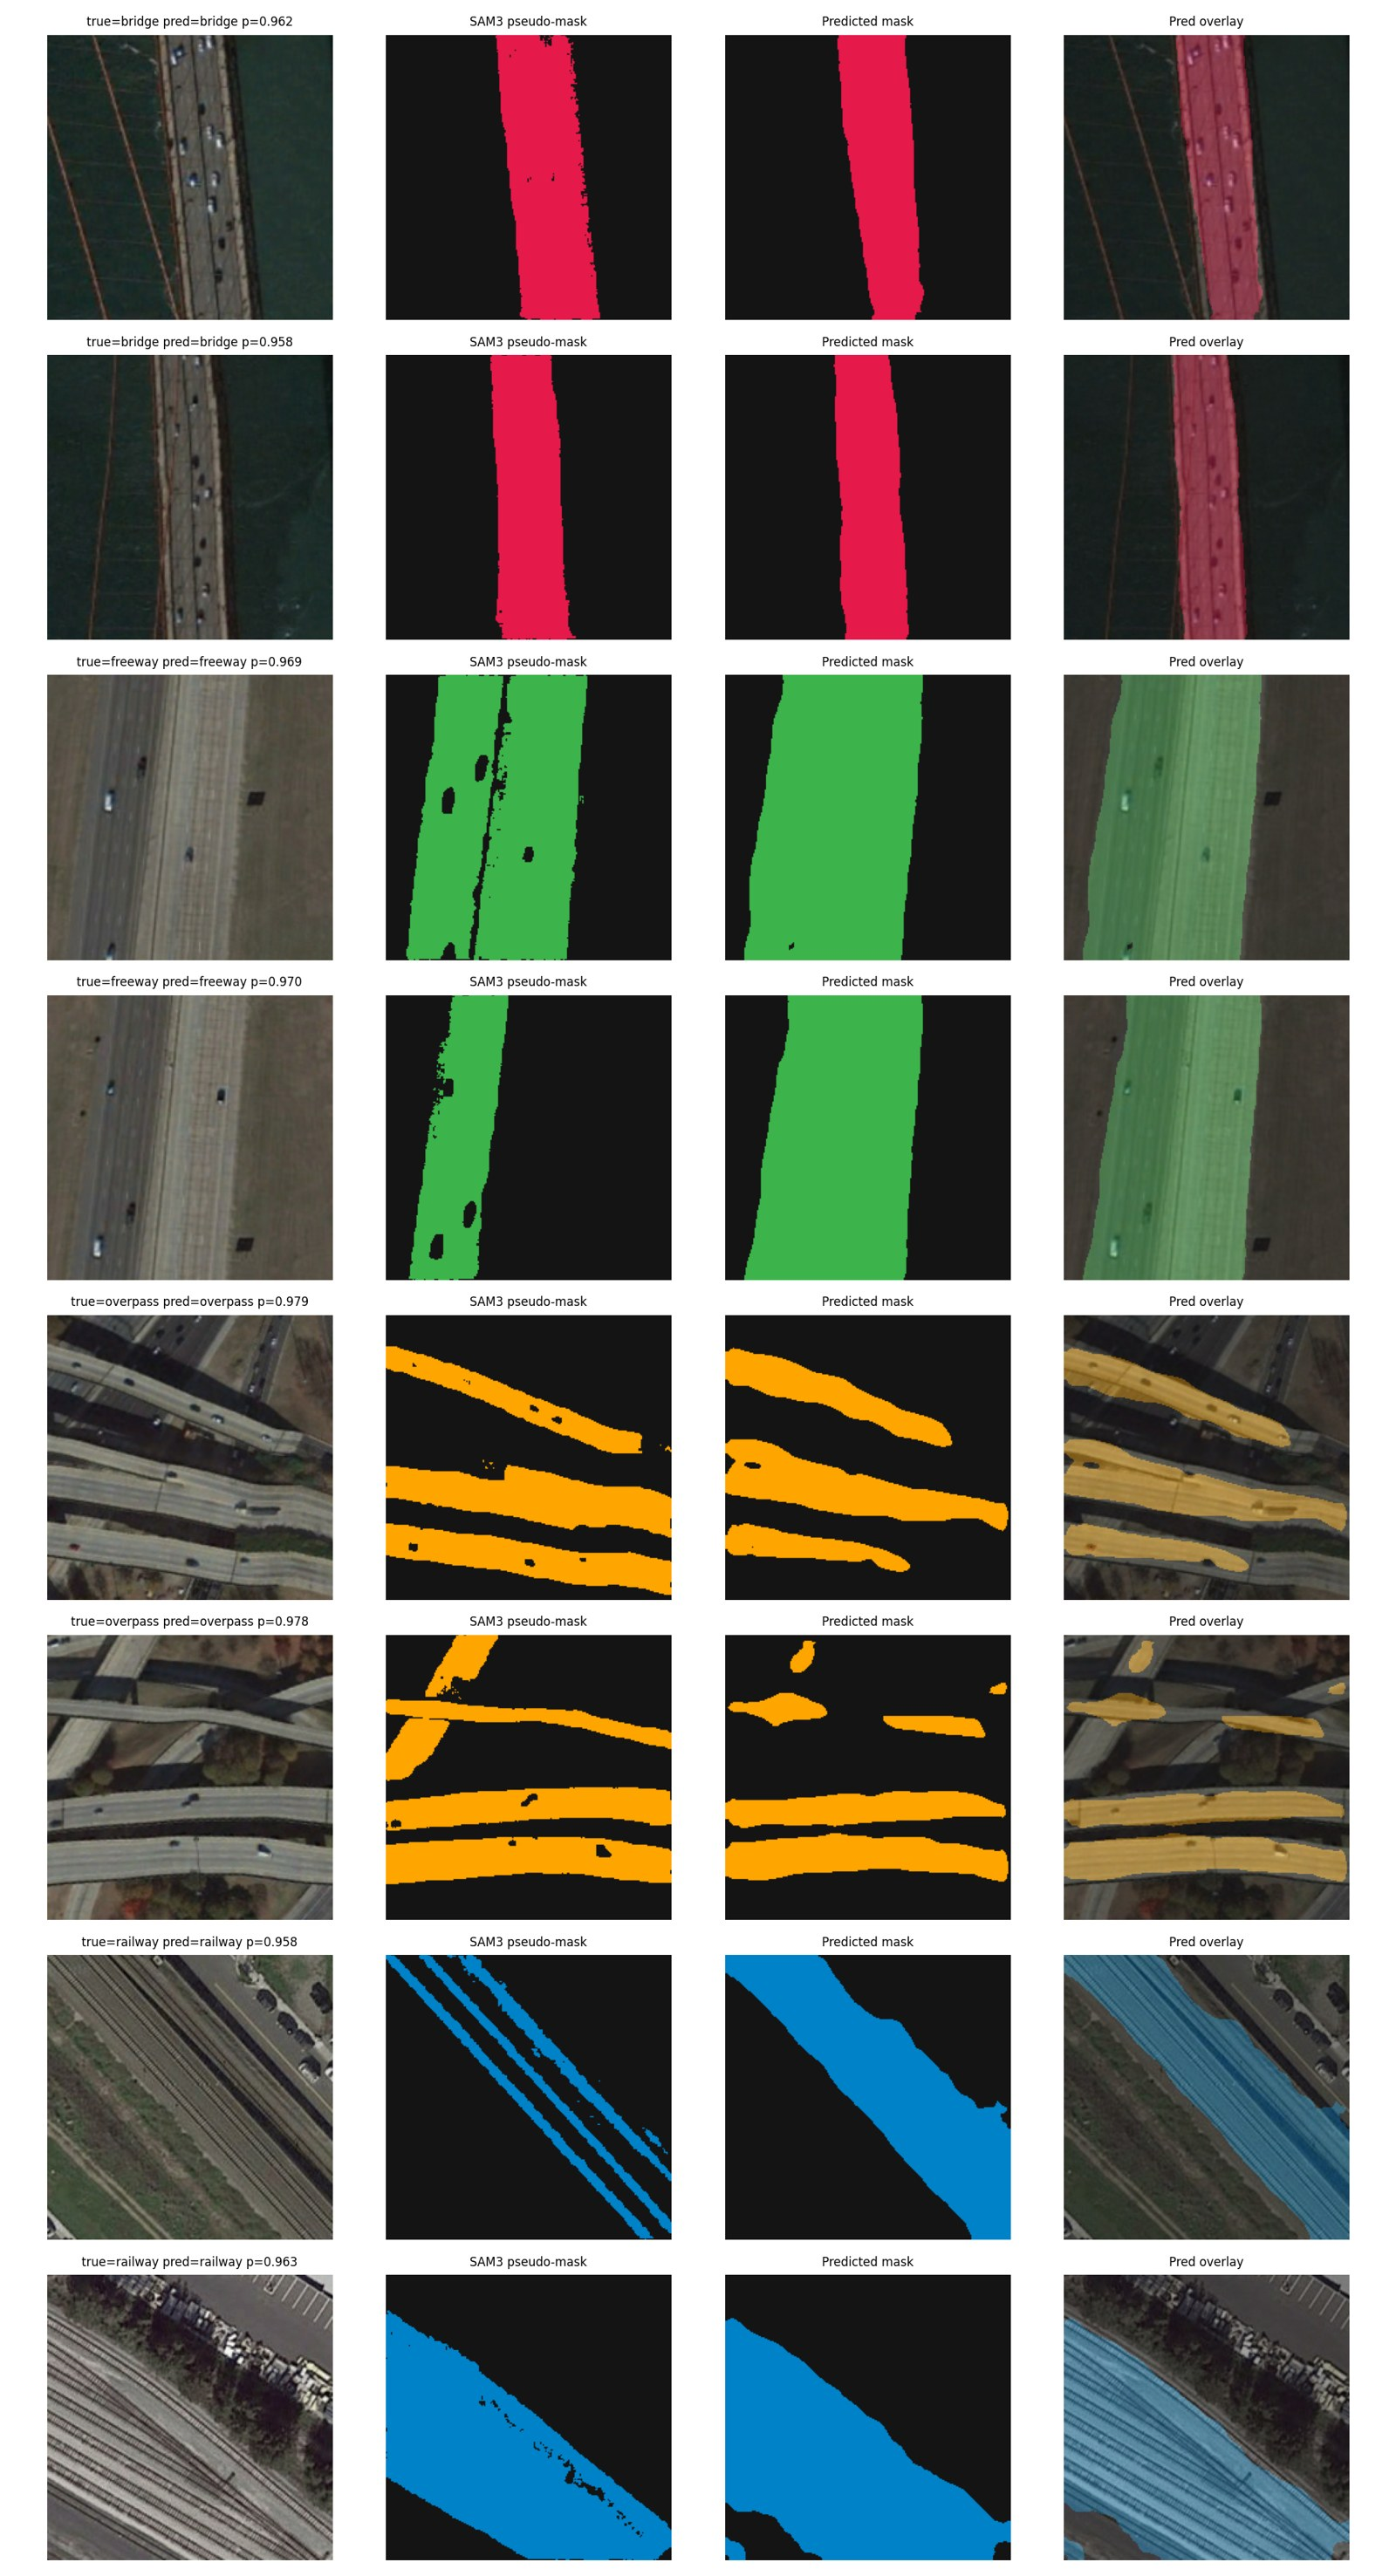

In [7]:
display_image_artifact(FIGURE_ARTIFACTS['Semantic-Guided CG-AF CNN SAM3 example grid'], 'Semantic-Guided CG-AF CNN SAM3 semantic transfer examples')

## 13. Why QAT, PTQ, and AWQ?

Because edge deployment is the priority, the notebook evaluates quantisation stability directly.

**QAT** (**Q**uantisation **A**ware **T**raining) exposes the model to fake W8A8 quantisation during training, so the model learns under quantised-like numerics instead of being quantised only after training.

**PTQ** (**P**ost **T**raining **Q**uantisation) is the basic post-training deployment test: calibrate activation ranges, quantise eligible Conv2d/Linear weights, and evaluate without retraining.

**AWQ** (**A**ctivation-Aware **W**eight **Q**uantisation) is a stronger calibration-aware quantisation check. It uses activation statistics to protect important weight channels during quantisation.

In this project, AWQ is used to answer whether the model remains robust under W8A8 and whether more aggressive W4A8 quantisation is viable.

## 14. Quantisation caveat

The PTQ/AWQ evaluation is a numerical deployment proxy, not a hardware export benchmark.

It does:

- store eligible Conv2d/Linear weights as integer buffers;
- use calibrated activation quantise/dequantise;
- evaluate whether the model numerically survives lower precision.

It does not yet do:

- ONNX/QNN/Core ML/LiteRT export;
- packed-kernel INT8 or INT4 acceleration;
- real NPU latency or energy benchmarking.

Therefore, the quantisation results support model robustness and size potential, but they are not hardware speed claims.

## 15. PEFT vs staged FFT under quantisation

Both Parameter Efficient Fine-Tuning (PEFT), in this case Transfer Learning with frozen encoder weights and staged Full Fine-Tuning (FFT) were evaluated for the same Semantic-Guided CG-AF CNN architecture. PEFT is useful because it is cheaper to adapt, but the final selection is based on post-training and post-quantisation stability.

**Semantic-Guided CG-AF CNN quantisation robustness summary**

,candidate,mode,weight_bits,activation_bits,awq_enabled,accuracy,macro_precision,macro_recall,macro_f1,seg_pixel_accuracy,seg_mean_iou,seg_mean_dice
0,fft,fp32,NaN,NaN,False,1.0000,1.0000,1.0000,1.0000,0.9327,0.8040,0.8873
1,fft,ptq_w8a8,8.0,8.0,False,1.0000,1.0000,1.0000,1.0000,0.9328,0.8043,0.8875
2,fft,awq_w8a8,8.0,8.0,True,1.0000,1.0000,1.0000,1.0000,0.9325,0.8036,0.8870
3,fft,ptq_w4a8,4.0,8.0,False,0.9964,0.9965,0.9964,0.9964,0.9120,0.7502,0.8514
4,fft,awq_w4a8,4.0,8.0,True,0.9982,0.9982,0.9982,0.9982,0.9136,0.7524,0.8536
5,peft,fp32,NaN,NaN,False,1.0000,1.0000,1.0000,1.0000,0.9172,0.7674,0.8627
6,peft,ptq_w8a8,8.0,8.0,False,0.9982,0.9982,0.9982,0.9982,0.9169,0.7667,0.8623
7,peft,awq_w8a8,8.0,8.0,True,1.0000,1.0000,1.0000,1.0000,0.9170,0.7666,0.8623
8,peft,ptq_w4a8,4.0,8.0,False,0.9536,0.9557,0.9536,0.9530,0.8705,0.6609,0.7907
9,peft,awq_w4a8,4.0,8.0,True,0.9804,0.9809,0.9804,0.9803,0.8848,0.6951,0.8140


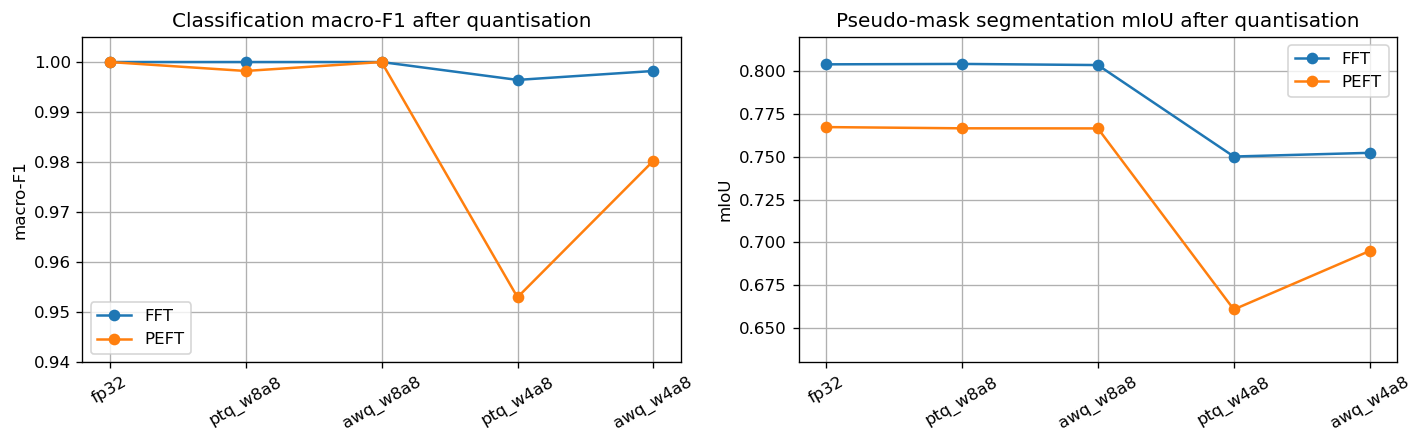

In [8]:
quant_summary = load_csv(ARTIFACTS['Actual quant summary'])
required_quant_columns = {
    'checkpoint_name', 'mode', 'classification_accuracy', 'macro_f1',
    'seg_pixel_accuracy', 'seg_mean_iou', 'seg_mean_dice'
}
assert required_quant_columns.issubset(quant_summary.columns), 'Quant summary schema changed.'
assert ((quant_summary['checkpoint_name'] == 'fft') & (quant_summary['mode'].astype(str).eq('fp32'))).any(), 'Missing FFT raw row.'
assert ((quant_summary['checkpoint_name'] == 'fft') & (quant_summary['mode'].astype(str).eq('awq_w8a8'))).any(), 'Missing FFT AWQ W8A8 row.'
assert ((quant_summary['checkpoint_name'] == 'peft') & (quant_summary['mode'].astype(str).eq('fp32'))).any(), 'Missing PEFT raw row.'
assert ((quant_summary['checkpoint_name'] == 'peft') & (quant_summary['mode'].astype(str).eq('awq_w8a8'))).any(), 'Missing PEFT AWQ W8A8 row.'
mode_order = ['fp32', 'awq_w8a8', 'ptq_w8a8', 'ptq_w4a8', 'awq_w4a8']
quant_summary['mode'] = pd.Categorical(quant_summary['mode'], categories=mode_order, ordered=True)
quant_summary = quant_summary.sort_values(['checkpoint_name', 'mode']).reset_index(drop=True)

quant_view = quant_summary[[
    'checkpoint_name', 'mode', 'weight_bits', 'activation_bits', 'awq_enabled',
    'classification_accuracy', 'macro_precision', 'macro_recall', 'macro_f1',
    'seg_pixel_accuracy', 'seg_mean_iou', 'seg_mean_dice'
]].rename(columns={
    'checkpoint_name': 'candidate',
    'classification_accuracy': 'accuracy',
})
display_table(quant_view, 'Semantic-Guided CG-AF CNN quantisation robustness summary')

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8), sharex=True)
for candidate, group in quant_summary.groupby('checkpoint_name', observed=False):
    axes[0].plot(group['mode'].astype(str), group['macro_f1'], marker='o', label=candidate.upper())
    axes[1].plot(group['mode'].astype(str), group['seg_mean_iou'], marker='o', label=candidate.upper())
axes[0].set_title('Classification macro-F1 after quantisation')
axes[0].set_ylabel('macro-F1')
axes[0].set_ylim(0.94, 1.005)
axes[1].set_title('Pseudo-mask segmentation mIoU after quantisation')
axes[1].set_ylabel('mIoU')
axes[1].set_ylim(0.63, 0.82)
for ax in axes:
    ax.tick_params(axis='x', rotation=30)
    ax.legend()
plt.tight_layout()
plt.show()

## 16. AWQ W8A8 stability check

The AWQ W8A8 comparison is the decisive stability check. PEFT is close, but one bridge sample flips to railway in the refreshed visual/evaluation pass. Staged FFT remains correct and has stronger segmentation quality.

Metric-source note: the full quantisation summary reports FFT AWQ W8A8 mIoU at approximately `0.8036`; the refreshed AWQ visual/comparison pass reports approximately `0.8034`. The small difference is from separate evaluation artifacts, not a different final model decision.

In [9]:
awq_export_summary = load_csv(ARTIFACTS['AWQ W8A8 summary'])
awq_examples = load_csv(ARTIFACTS['AWQ example metadata'])
assert set(awq_export_summary['quant_mode']).issubset({'awq_w8a8'}), 'Mask-export summary must be AWQ W8A8.'
assert set(awq_examples['quant_mode']).issubset({'awq_w8a8'}), 'Mask-export manifest must be AWQ W8A8.'
required_checkpoints = {'peft', 'fft'}
assert required_checkpoints.issubset(set(awq_export_summary['checkpoint'])), 'Missing expected AWQ W8A8 checkpoint rows.'
awq_summary = awq_export_summary.assign(
    model=lambda df: df['checkpoint'] + '_awq_w8a8',
    accuracy=lambda df: df['classification_accuracy'],
    macro_f1=lambda df: df['classification_macro_f1'],
    seg_pixel_accuracy=lambda df: df['seg_pixel_accuracy_vs_sam3'],
    seg_mean_iou=lambda df: df['seg_mean_iou_vs_sam3'],
    seg_mean_dice=lambda df: df['seg_mean_dice_vs_sam3'],
)
per_scene_rows = []
for checkpoint in ['peft', 'fft']:
    pred_col = f'{checkpoint}_pred_scene_name'
    iou_col = f'{checkpoint}_iou'
    dice_col = f'{checkpoint}_dice'
    pixel_col = f'{checkpoint}_pixel_accuracy'
    temp = awq_examples.assign(classification_correct=awq_examples[pred_col].eq(awq_examples['true_scene_name']))
    grouped = temp.groupby('scene_class_name', as_index=False).agg(
        samples=('export_id', 'count'),
        classification_correct=('classification_correct', 'sum'),
        classification_accuracy=('classification_correct', 'mean'),
        seg_pixel_accuracy=(pixel_col, 'mean'),
        seg_mean_iou=(iou_col, 'mean'),
        seg_mean_dice=(dice_col, 'mean'),
    )
    grouped.insert(0, 'model', f'{checkpoint}_awq_w8a8')
    grouped = grouped.rename(columns={'scene_class_name': 'scene'})
    per_scene_rows.append(grouped)
awq_scene = pd.concat(per_scene_rows, ignore_index=True)
display_table(awq_summary[[
    'model', 'accuracy', 'macro_f1', 'seg_pixel_accuracy', 'seg_mean_iou', 'seg_mean_dice'
]], 'AWQ W8A8 PEFT vs staged FFT summary')
display_table(awq_scene[[
    'model', 'scene', 'samples', 'classification_accuracy', 'classification_correct',
    'seg_pixel_accuracy', 'seg_mean_iou', 'seg_mean_dice'
]], 'AWQ W8A8 per-scene metrics')

**AWQ W8A8 PEFT vs staged FFT summary**

,model,accuracy,macro_f1,seg_pixel_accuracy,seg_mean_iou,seg_mean_dice,confusion_matrix
0,peft_awq_w8a8,0.9982,0.9982,0.9167,0.7663,0.8621,"[[139, 0, 0, 1], [0, 140, 0, 0], [0, 0, 140, 0..."
1,fft_awq_w8a8,1.0000,1.0000,0.9324,0.8034,0.8869,"[[140, 0, 0, 0], [0, 140, 0, 0], [0, 0, 140, 0..."


**AWQ W8A8 per-scene metrics**

,model,scene,samples,classification_accuracy,classification_correct,seg_pixel_accuracy,seg_mean_iou,seg_mean_dice
0,peft_awq_w8a8,bridge,140,0.9929,139,0.9424,0.4285,0.4607
1,peft_awq_w8a8,freeway,140,1.0000,140,0.9507,0.6040,0.6338
2,peft_awq_w8a8,overpass,140,1.0000,140,0.8821,0.4851,0.5572
3,peft_awq_w8a8,railway,140,1.0000,140,0.8916,0.3795,0.4294
4,fft_awq_w8a8,bridge,140,1.0000,140,0.9531,0.8824,0.9365
5,fft_awq_w8a8,freeway,140,1.0000,140,0.9616,0.9261,0.9616
6,fft_awq_w8a8,overpass,140,1.0000,140,0.9019,0.7659,0.8627
7,fft_awq_w8a8,railway,140,1.0000,140,0.9131,0.7983,0.8849


## 17. Model size and edge deployment

The deployment-style model state size is the same for PEFT and FFT because the architecture is the same. The difference is training/checkpoint metadata and the final learned weights, not the deployable architecture.

**FFT deployment-style model size by quantisation mode**

,checkpoint,mode,weight_bits,activation_bits,state_tensor_mib_emulated,state_tensor_mib_theoretical_packed,compression_vs_fp32_tensor,compression_vs_fp32_theoretical
6,fft,fp32,NaN,NaN,108.5395,108.5395,1.000x,1.000x
7,fft,fp16,16.0,16.0,54.2697,54.2697,2.000x,2.000x
8,fft,ptq_w8a8,8.0,8.0,27.5228,27.5228,3.944x,3.944x
10,fft,awq_w8a8,8.0,8.0,27.6930,27.6930,3.919x,3.919x
9,fft,ptq_w4a8,4.0,8.0,27.5228,13.9927,3.944x,7.757x
11,fft,awq_w4a8,4.0,8.0,27.6930,14.1630,3.919x,7.664x


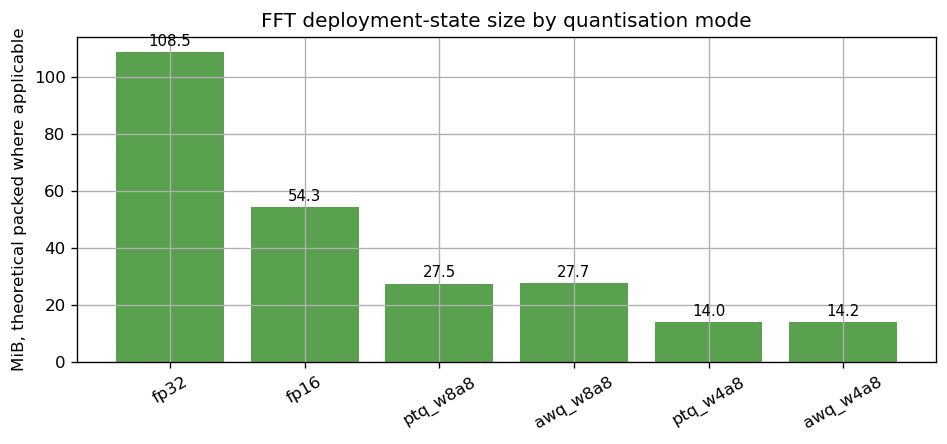

In [10]:
size_summary = load_csv(ARTIFACTS['Model size summary'])
size_fft = size_summary.loc[size_summary['checkpoint'].eq('fft')].copy()
size_order = ['fp32', 'fp16', 'ptq_w8a8', 'awq_w8a8', 'ptq_w4a8', 'awq_w4a8']
size_fft['mode'] = pd.Categorical(size_fft['mode'], categories=size_order, ordered=True)
size_fft = size_fft.sort_values('mode')
size_view = size_fft[[
    'checkpoint', 'mode', 'weight_bits', 'activation_bits',
    'state_tensor_mib_emulated', 'state_tensor_mib_theoretical_packed',
    'compression_vs_fp32_tensor', 'compression_vs_fp32_theoretical'
]]
display_table(size_view, 'FFT deployment-style model size by quantisation mode')

fig, ax = plt.subplots(figsize=(8, 3.8))
ax.bar(size_fft['mode'].astype(str), size_fft['state_tensor_mib_theoretical_packed'], color='#59A14F')
ax.set_title('FFT deployment-state size by quantisation mode')
ax.set_ylabel('MiB, theoretical packed where applicable')
ax.tick_params(axis='x', rotation=30)
for index, value in enumerate(size_fft['state_tensor_mib_theoretical_packed']):
    ax.text(index, value + 1.2, f'{value:.1f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

## 18. Confusion matrices

The bottom-line classification confusion matrix is the staged FFT AWQ W8A8 result. The class order is `bridge`, `freeway`, `overpass`, `railway`.

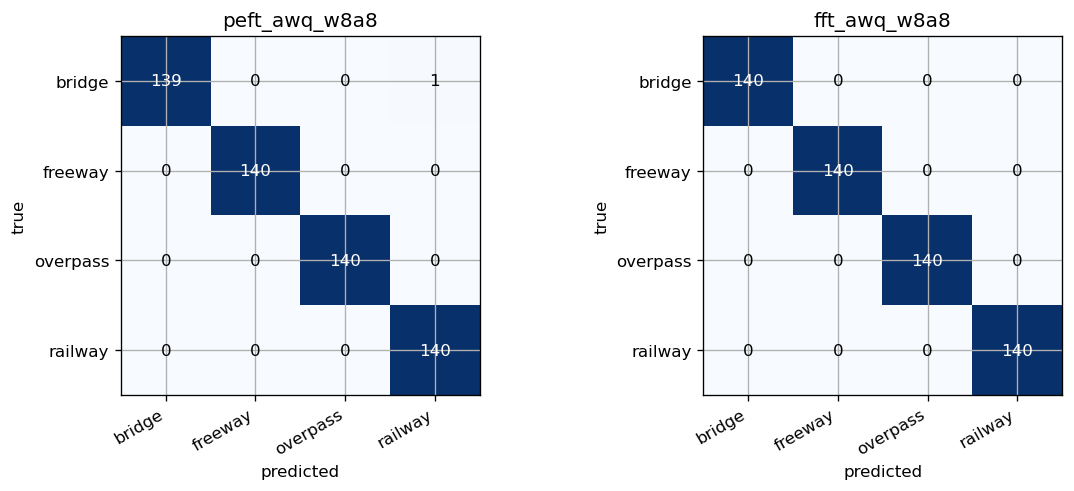

In [11]:
def plot_confusion(ax, matrix: np.ndarray, title: str) -> None:
    image = ax.imshow(matrix, cmap='Blues')
    ax.set_title(title)
    ax.set_xlabel('predicted')
    ax.set_ylabel('true')
    ax.set_xticks(range(len(CLASS_NAMES)), labels=CLASS_NAMES, rotation=30, ha='right')
    ax.set_yticks(range(len(CLASS_NAMES)), labels=CLASS_NAMES)
    max_value = matrix.max() if matrix.size else 0
    threshold = max_value / 2 if max_value else 0
    for row in range(matrix.shape[0]):
        for col in range(matrix.shape[1]):
            color = 'white' if matrix[row, col] > threshold else 'black'
            ax.text(col, row, str(matrix[row, col]), ha='center', va='center', color=color, fontsize=10)
    return image

def confusion_from_examples(df: pd.DataFrame, pred_col: str) -> np.ndarray:
    matrix = np.zeros((len(CLASS_NAMES), len(CLASS_NAMES)), dtype=int)
    class_to_idx = {name: idx for idx, name in enumerate(CLASS_NAMES)}
    for _, row in df.iterrows():
        true_idx = class_to_idx[row['true_scene_name']]
        pred_idx = class_to_idx[row[pred_col]]
        matrix[true_idx, pred_idx] += 1
    return matrix

fig, axes = plt.subplots(1, 2, figsize=(10, 4.2))
for ax, checkpoint in zip(axes, ['peft', 'fft']):
    cm = confusion_from_examples(awq_examples, f'{checkpoint}_pred_scene_name')
    plot_confusion(ax, cm, f'{checkpoint}_awq_w8a8')
plt.tight_layout()
plt.show()

## 19. Qualitative AWQ W8A8 semantic evidence

The exported review panels compare PEFT, FFT, and SAM3 pseudo-labels under AWQ W8A8. They should be read as qualitative/non-parity evidence rather than a claim that one mask is visually best in every case. SAM3, PEFT, and FFT have different failure modes: SAM3 can over-cover the scene, PEFT can produce tighter object-like masks but is less stable after quantisation, and FFT often matches the pseudo-label objective more strongly.

The notebook displays one AWQ W8A8 comparison panel per class from the pipeline mask-export manifest. The full exported panel set is available in the pipeline mask figure directory.

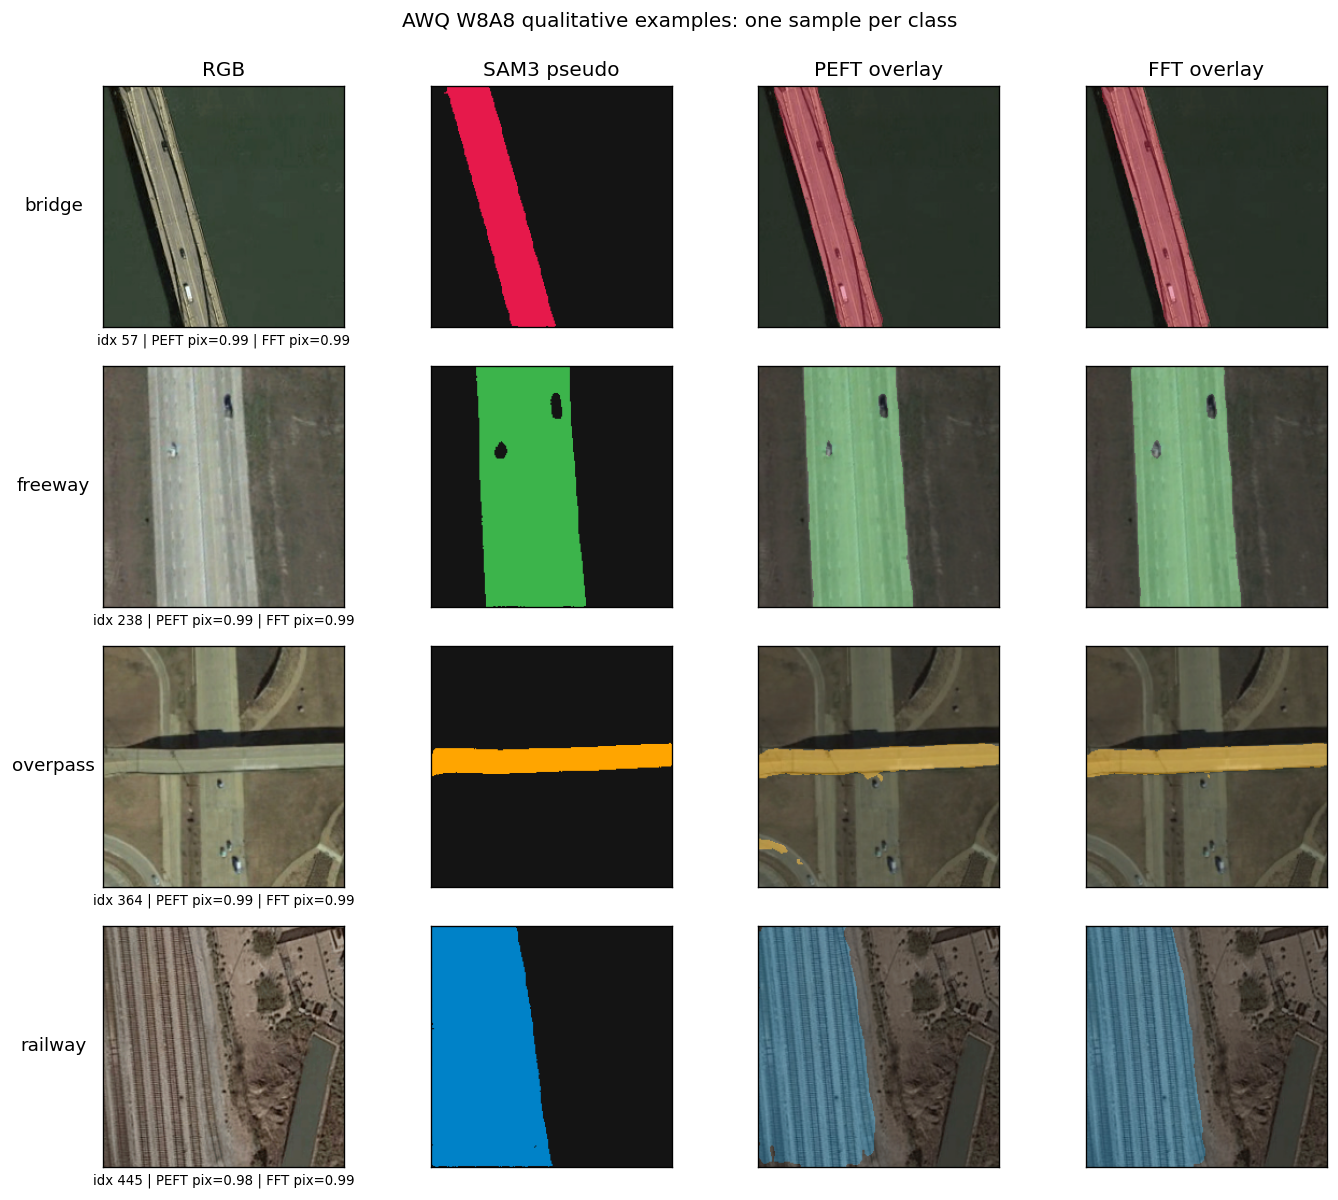

**Displayed qualitative example metadata**

,scene_true,index,peft_pred,peft_confidence,peft_pixel_acc,fft_pred,fft_confidence,fft_pixel_acc,joint_pixel_acc
0,bridge,57,bridge,1.0,0.9949,bridge,0.9613,0.9938,0.9938
1,freeway,238,freeway,1.0,0.9920,freeway,0.9583,0.9935,0.9920
2,overpass,364,overpass,1.0,0.9853,overpass,0.9659,0.9940,0.9853
3,railway,445,railway,1.0,0.9821,railway,0.9621,0.9870,0.9821


**Qualitative contact sheets omitted by default**

,sheet,available
0,PEFT worst cases,True
1,FFT worst cases,True
2,Largest FFT pseudo-label advantage cases,True


In [12]:
example_metadata = load_csv(ARTIFACTS['AWQ example metadata']).copy()
example_metadata['joint_pixel_acc'] = example_metadata[['peft_pixel_accuracy', 'fft_pixel_accuracy']].min(axis=1)
selected_examples = (
    example_metadata.sort_values(['scene_class_name', 'joint_pixel_acc'], ascending=[True, False])
    .groupby('scene_class_name', as_index=False)
    .head(1)
    .set_index('scene_class_name')
    .loc[CLASS_NAMES]
)

for scene, row in selected_examples.iterrows():
    panel_path = Path(row['comparison_panel_path'])
    if not panel_path.is_absolute():
        panel_path = PROJECT_ROOT / panel_path
    display_image_artifact(panel_path, f'AWQ W8A8 review panel — {scene}', width=1200)

display_table(
    selected_examples.reset_index()[[
        'scene_class_name', 'row_number', 'true_scene_name', 'peft_pred_scene_name',
        'peft_pixel_accuracy', 'fft_pred_scene_name', 'fft_pixel_accuracy', 'joint_pixel_acc',
        'comparison_panel_path',
    ]],
    'Displayed AWQ W8A8 qualitative example metadata',
)

## 20. Final selected result and quantisation interpretation

The selected architecture remains the staged FFT `Semantic-Guided CG-AF CNN`. The quantisation story has two distinct roles:

1. **AWQ-style W8A8 PyTorch emulation** is a custom activation-aware research/proxy implementation. It is used to test whether the model remains robust under state-of-the-art activation-aware quantisation ideas and to study segmentation/classification stability. It should not be described as a native ONNX/NPU deployment artifact.
2. **Full-calibrated ONNX INT8 QDQ** is the deployment-realistic artifact. It uses standard ONNX Runtime static post-training quantisation with calibration, producing a portable QDQ graph that is more likely to map onto mobile/edge NPU compilation paths.

So the final result is not “AWQ deployment”. The final result is: **Semantic-Guided CG-AF CNN selected by the AWQ-style robustness study, then deployed through calibrated ONNX INT8 QDQ for practical edge delivery.**


In [ ]:
final_awq_eval = quant_summary.loc[
    quant_summary['checkpoint_name'].eq('fft') & quant_summary['mode'].astype(str).eq('awq_w8a8')
].iloc[0]
final_awq = awq_summary.loc[awq_summary['model'].eq('fft_awq_w8a8')].iloc[0]
final_size = size_summary.loc[
    size_summary['checkpoint'].eq('fft') & size_summary['mode'].eq('awq_w8a8')
].iloc[0]

onnx_delivery_path = TABLES_DIR / 'semantic_guided_cgaf_unseen_val12_fullcalib_minmax_20260616' / 'onnx_delivery_size_summary.csv'
onnx_val12_summary_path = TABLES_DIR / 'semantic_guided_cgaf_unseen_val12_fullcalib_minmax_20260616' / 'summary.csv'
if onnx_delivery_path.exists() and onnx_val12_summary_path.exists():
    onnx_delivery_now = load_csv(onnx_delivery_path)
    onnx_val12_now = load_csv(onnx_val12_summary_path)
    int8_delivery = onnx_delivery_now.loc[onnx_delivery_now['artifact'].eq('onnx_int8_qdq_fullcalib_minmax')].iloc[0]
    fp32_delivery = onnx_delivery_now.loc[onnx_delivery_now['artifact'].eq('onnx_fp32')].iloc[0]
    onnx_int8_val12 = onnx_val12_now.loc[onnx_val12_now['variant'].eq('onnx_int8_qdq')].iloc[0]
    onnx_deployment_rows = f'''
| Native deployable artifact | Full-calibrated ONNX INT8 QDQ |
| ONNX INT8 val12 accuracy | {onnx_int8_val12['accuracy']:.4f} |
| ONNX INT8 raw artifact size | {int8_delivery['raw_mib']:.2f} MiB |
| ONNX INT8 compressed delivery size | {int8_delivery['gzip_mib']:.2f} MiB |
| Compressed INT8 vs compressed FP32 | {fp32_delivery['gzip_mib'] / int8_delivery['gzip_mib']:.2f}x smaller |'''
else:
    onnx_deployment_rows = '\n| Native deployable artifact | Full-calibrated ONNX INT8 QDQ; see Section 23 after generating ONNX artifacts |'

summary_md = f'''
### Final model decision

| Item | Value |
|---|---:|
| Selected architecture | Semantic-Guided CG-AF CNN |
| Selected adaptation | QAT staged FFT |
| Research quantisation stress test | Custom AWQ-style W8A8 PyTorch emulation |
| AWQ-style purpose | Activation-aware robustness/proxy evaluation, not native deployment |
| AWQ-style macro-F1 | {final_awq['macro_f1']:.4f} |
| AWQ-style pseudo-mask mIoU | {final_awq['seg_mean_iou']:.4f} |
| AWQ-style theoretical packed state size | {final_size['state_tensor_mib_theoretical_packed']:.2f} MiB |
| AWQ-style compression versus FP32 | {final_size['compression_vs_fp32_theoretical']} |{onnx_deployment_rows}

**Decision:** choose staged FFT because it is stable under the custom activation-aware AWQ-style stress test and preserves stronger semantic segmentation quality. For realistic deployment, use the full-calibrated ONNX INT8 QDQ artifact rather than treating the custom AWQ-style PyTorch emulation as a native NPU artifact.
'''
display(Markdown(summary_md))


## 21. Limitations

Important limitations to keep explicit:

- SAM3 masks are pseudo-labels, not human-verified ground truth.
- The classification result validates the segmentation-guided semantic distillation pipeline, not a pure image-only classifier.
- The AWQ-style W8A8 path is a custom PyTorch emulation/proxy for activation-aware quantisation robustness, not a native ONNX/NPU deployment format.
- The native deployment path is ONNX Runtime static INT8 QDQ/PTQ with calibration.
- ONNX export alone does not guarantee full NPU execution; target execution-provider/compiler validation is still required.
- Backend-specific hardware latency and energy profiling remain future work.


## 22. Generated artifacts

The final report-ready artifacts used by this notebook are listed below.

In [14]:
final_artifacts = pd.DataFrame([
    {'type': 'pipeline manifest', 'location': 'local', 'path': str(PIPELINE_MANIFEST_PATH.relative_to(PROJECT_ROOT))},
    {'type': 'quant summary', 'location': 'local', 'path': str(pipeline_output_path('quant_summary').relative_to(PROJECT_ROOT))},
    {'type': 'checkpoint export manifest', 'location': 'local', 'path': str(pipeline_output_path('checkpoint_export_manifest').relative_to(PROJECT_ROOT))},
    {'type': 'FFT raw checkpoint export', 'location': 'local/remote artifact mirror', 'path': str(pipeline_output_path('fft_raw_checkpoint_export'))},
    {'type': 'PEFT raw checkpoint export', 'location': 'local/remote artifact mirror', 'path': str(pipeline_output_path('peft_raw_checkpoint_export'))},
    {'type': 'FFT AWQ W8A8 checkpoint export', 'location': 'local/remote artifact mirror', 'path': str(pipeline_output_path('fft_awq_checkpoint'))},
    {'type': 'PEFT AWQ W8A8 checkpoint export', 'location': 'local/remote artifact mirror', 'path': str(pipeline_output_path('peft_awq_checkpoint'))},
    {'type': 'AWQ mask export manifest', 'location': 'local', 'path': str(mask_export_manifest_path.relative_to(PROJECT_ROOT))},
    {'type': 'AWQ mask figure dir', 'location': 'local', 'path': str(mask_figure_dir.relative_to(PROJECT_ROOT))},
])
final_artifacts['available_for_notebook'] = final_artifacts['path'].map(lambda value: Path(value).exists() if Path(value).is_absolute() else (PROJECT_ROOT / value).exists())
display_table(final_artifacts[['type', 'location', 'available_for_notebook']], 'Notebook artifact index')

**Notebook artifact index**

,type,location,available_for_notebook
0,actual quant table dir,local,True
1,AWQ comparison table dir,local,True
2,AWQ comparison figure dir,local,True
3,selected FFT checkpoint,remote vaporeon snapshot,remote


## 23. Native ONNX export, full-calibrated INT8 QDQ, and edge delivery

This section attaches the native ONNX deployment lane after the AWQ/W8A8 proxy analysis above. It uses the same BF16-trained staged FFT checkpoint, but follows the deployable ONNX path:

1. BF16-trained `Semantic-Guided CG-AF CNN` FFT checkpoint;
2. dynamic-batch FP32 ONNX export with outputs `segmentation_logits` and `scene_logits`;
3. ONNX Runtime static INT8 QDQ/PTQ with full train-split calibration (`MinMax`, 2240 calibration images);
4. unseen `data/val 12` ImageFolder evaluation for Torch BF16, ONNX FP32, and ONNX INT8 QDQ.

The ONNX INT8 result below is **standard calibrated QDQ/PTQ**, not ONNX AWQ. The AWQ-style lane remains a PyTorch emulation/proxy, while ONNX QDQ is the native deployment artifact.


In [ ]:
ONNX_EVAL_DIR = TABLES_DIR / 'semantic_guided_cgaf_onnx_eval_fullcalib_minmax_20260616'
ONNX_VAL12_TABLE_DIR = TABLES_DIR / 'semantic_guided_cgaf_unseen_val12_fullcalib_minmax_20260616'
ONNX_VAL12_REVIEW_DIR = FIGURES_DIR / 'semantic_guided_cgaf_unseen_val12_review_fullcalib_minmax_20260616'
ONNX_VAL12_MASK_DIR = FIGURES_DIR / 'semantic_guided_cgaf_unseen_val12_masks_fullcalib_minmax_20260616'

onnx_artifacts = pd.DataFrame([
    {'artifact': 'ONNX full-calibrated comparison table', 'path': ONNX_EVAL_DIR / 'comparison_table.csv'},
    {'artifact': 'ONNX runtime summary', 'path': ONNX_EVAL_DIR / 'runtime_summary.csv'},
    {'artifact': 'ONNX drift summary', 'path': ONNX_EVAL_DIR / 'drift_summary.csv'},
    {'artifact': 'Unseen val12 summary', 'path': ONNX_VAL12_TABLE_DIR / 'summary.csv'},
    {'artifact': 'Unseen val12 per-image predictions', 'path': ONNX_VAL12_TABLE_DIR / 'per_image_predictions.csv'},
    {'artifact': 'ONNX delivery size summary', 'path': ONNX_VAL12_TABLE_DIR / 'onnx_delivery_size_summary.csv'},
    {'artifact': 'Near-confusion pair summary', 'path': ONNX_VAL12_REVIEW_DIR / 'onnx_near_confusion_pair_summary.csv'},
    {'artifact': 'Near-confusion low-margin examples', 'path': ONNX_VAL12_REVIEW_DIR / 'onnx_lowest_margin_top20.csv'},
    {'artifact': 'Corrected val12 review figures', 'path': ONNX_VAL12_REVIEW_DIR},
    {'artifact': 'Full-calibrated val12 predicted masks', 'path': ONNX_VAL12_MASK_DIR},
])
onnx_artifacts['exists'] = onnx_artifacts['path'].map(lambda p: Path(p).exists())
onnx_artifacts['relative_path'] = onnx_artifacts['path'].map(lambda p: str(Path(p).relative_to(PROJECT_ROOT)) if Path(p).is_relative_to(PROJECT_ROOT) else str(p))
display_table(onnx_artifacts[['artifact', 'exists', 'relative_path']], 'Native ONNX artifact availability')
assert onnx_artifacts['exists'].all(), 'Missing ONNX artifacts: ' + ', '.join(onnx_artifacts.loc[~onnx_artifacts['exists'], 'relative_path'])

onnx_eval = load_csv(ONNX_EVAL_DIR / 'comparison_table.csv')
onnx_runtime = load_csv(ONNX_EVAL_DIR / 'runtime_summary.csv')
onnx_drift = load_csv(ONNX_EVAL_DIR / 'drift_summary.csv')
val12_summary = load_csv(ONNX_VAL12_TABLE_DIR / 'summary.csv')
val12_predictions = load_csv(ONNX_VAL12_TABLE_DIR / 'per_image_predictions.csv')
onnx_delivery = load_csv(ONNX_VAL12_TABLE_DIR / 'onnx_delivery_size_summary.csv')
near_margin = load_csv(ONNX_VAL12_REVIEW_DIR / 'onnx_near_confusion_margin_summary.csv')
near_pairs = load_csv(ONNX_VAL12_REVIEW_DIR / 'onnx_near_confusion_pair_summary.csv')
near_lowest = load_csv(ONNX_VAL12_REVIEW_DIR / 'onnx_lowest_margin_top20.csv')


### Corrected ONNX confusion matrices on unseen `val 12`

The confusion matrices here are computed from the unseen `data/val 12` ImageFolder evaluation, not from the earlier AWQ qualitative mask-export subset. After full train-split MinMax calibration, ONNX INT8 QDQ reaches the same 400/400 classification accuracy as Torch BF16 and ONNX FP32.


In [ ]:
val12_view = val12_summary[[
    'variant', 'runtime', 'precision_mode', 'observed_images', 'accuracy', 'macro_f1',
    'scene_pred_agreement_vs_reference', 'seg_pixel_agreement_vs_reference',
]].copy()
display_table(val12_view, 'Unseen val12 classification and segmentation-logit agreement')

for variant, title in [
    ('torch_bf16', 'Torch BF16 val12 confusion'),
    ('onnx_fp32', 'ONNX FP32 val12 confusion'),
    ('onnx_int8_qdq', 'ONNX INT8 QDQ full-calibrated val12 confusion'),
]:
    display_image_artifact(
        ONNX_VAL12_REVIEW_DIR / 'plots' / f'{variant}_confusion_counts.png',
        title,
        width=700,
    )


### Potential almost-confused classes

Mean confidence is less useful when nearly all examples are easy. The more diagnostic signal is the **top-1 vs top-2 margin** and the runner-up class. Smaller margins indicate classes that the model nearly confused.

After full INT8 calibration there are no classification errors, but the remaining low-margin case is still informative: `railway701.jpg` is correctly predicted as `railway`, with `freeway` as runner-up.


In [ ]:
display_table(
    near_margin[[
        'variant', 'images', 'min_margin', 'p01_margin', 'p05_margin', 'p10_margin',
        'median_margin', 'max_runner_up_probability', 'count_margin_lt_0_50',
        'count_margin_lt_0_35', 'count_margin_lt_0_25',
    ]],
    'ONNX near-confusion margin summary',
)

int8_pairs = near_pairs.loc[near_pairs['variant'].eq('onnx_int8_qdq'), [
    'true_class_name', 'runner_up_class_name', 'count', 'min_margin',
    'max_runner_up_probability', 'count_margin_lt_0_50', 'count_margin_lt_0_35',
]].head(12)
display_table(int8_pairs, 'ONNX INT8 QDQ almost-confused class pairs')

int8_lowest = near_lowest.loc[near_lowest['variant'].eq('onnx_int8_qdq'), [
    'image_name', 'true_class_name', 'predicted_class_name', 'runner_up_class_name',
    'top1_probability', 'runner_up_probability', 'top1_top2_margin',
]].head(10)
display_table(int8_lowest, 'Lowest-margin ONNX INT8 QDQ examples')

for path, title in [
    (ONNX_VAL12_REVIEW_DIR / 'plots' / 'onnx_int8_qdq_near_confusion_min_margin.png', 'ONNX INT8 QDQ lowest margin by true/runner-up class'),
    (ONNX_VAL12_REVIEW_DIR / 'plots' / 'onnx_int8_qdq_near_confusion_max_runner_up_probability.png', 'ONNX INT8 QDQ highest runner-up probability by true/runner-up class'),
]:
    display_image_artifact(path, title, width=800)


### Qualitative masks from the corrected ONNX val12 run

These are predicted masks only: `val 12` does not contain segmentation ground truth, so no mIoU is reported for this split. The panels show RGB plus Torch BF16, ONNX FP32, and full-calibrated ONNX INT8 QDQ masks.


In [ ]:
display_image_artifact(
    ONNX_VAL12_REVIEW_DIR / 'sample_panels_contact_sheet.png',
    'Unseen val12 sample panels: RGB + Torch BF16 / ONNX FP32 / ONNX INT8 QDQ masks',
    width=1100,
)
display_image_artifact(
    ONNX_VAL12_REVIEW_DIR / 'sample_panels' / 'railway_railway701_comparison_panel.png',
    'Borderline but correct case after full calibration: railway701',
    width=1000,
)


### ONNX export/evaluation performance and deployable payload

The ONNX evaluator validates the FP32 ONNX and calibrated INT8 QDQ artifacts against the BF16-trained checkpoint. Runtime measurements below use the available execution provider in the experiment environment; ONNX Runtime CUDA was not available on `vaporeon`, so ONNX rows were measured with `CPUExecutionProvider`. The more important deployment result for this section is correctness stability, graph portability, and payload size.


In [ ]:
onnx_eval_view = onnx_eval.loc[
    onnx_eval['variant'].isin(['torch_bf16', 'onnx_fp32', 'onnx_int8_qdq']),
    [
        'variant', 'runtime', 'device_or_provider', 'precision_mode', 'native_deployment_artifact',
        'calibration_image_count', 'calibration_method', 'classification_accuracy',
        'seg_mean_iou_vs_sam3', 'scene_pred_agreement_vs_torch_fp32',
        'seg_pixel_agreement_vs_torch_fp32', 'artifact_size_bytes',
    ],
].copy()
onnx_eval_view['artifact_mib'] = onnx_eval_view['artifact_size_bytes'] / (1024 * 1024)
display_table(onnx_eval_view, 'Full-calibrated ONNX evaluator summary')

delivery_view = onnx_delivery[[
    'artifact', 'raw_mib', 'gzip_mib', 'gzip_ratio', 'raw_path', 'gzip_path',
]].copy()
display_table(delivery_view, 'ONNX edge-delivery payload size')

fp32 = onnx_delivery.loc[onnx_delivery['artifact'].eq('onnx_fp32')].iloc[0]
int8 = onnx_delivery.loc[onnx_delivery['artifact'].eq('onnx_int8_qdq_fullcalib_minmax')].iloc[0]
edge_delivery_md = f'''
**Edge-delivery calculation**

- FP32 ONNX: {fp32['raw_mib']:.2f} MiB raw, {fp32['gzip_mib']:.2f} MiB gzip/DEFLATE.
- Full-calibrated INT8 QDQ ONNX: {int8['raw_mib']:.2f} MiB raw, {int8['gzip_mib']:.2f} MiB gzip/DEFLATE.
- Raw INT8 is {fp32['raw_mib'] / int8['raw_mib']:.2f}x smaller than raw FP32 ONNX.
- Compressed INT8 is {fp32['gzip_mib'] / int8['gzip_mib']:.2f}x smaller than compressed FP32 ONNX.

At 3–5 Mbps GEO uplink rates, the 18.70 MiB compressed INT8 payload corresponds to roughly 30–60 seconds of airtime before protocol/weather/congestion overhead.
'''
display(Markdown(edge_delivery_md))


### Deployment interpretation

The native ONNX lane supports the architectural feasibility argument: the model keeps its dominant workload in CNN-style operators, exports to standard ONNX, and can be calibrated into an INT8 QDQ graph. That is a more realistic NPU path than relying on arbitrary transformer attention patterns or custom AWQ operators.

The report wording should stay precise:

- **Use:** “ONNX Runtime static INT8 QDQ post-training quantization with full calibration.”
- **Use:** “AWQ-style W8A8 PyTorch emulation/proxy” for the separate activation-aware robustness study.
- **Avoid:** “ONNX AWQ deployment” or “NPU-ready AWQ checkpoint.”

Operationally, the corrected INT8 result is attractive: the calibrated INT8 ONNX artifact is 27.96 MiB raw and 18.70 MiB compressed, while preserving 400/400 scene accuracy on the unseen `val 12` split. AWQ is retained as evidence that the architecture tolerates activation-aware quantisation pressure; ONNX INT8 QDQ is the deployable artifact chosen for practical edge delivery.
